# Data Cleaning
1. Dropping any rows with lsoa_code missing in street_crimes
2. Checking in lsoa_info if any lsoa code is missing from official list
3. Create month_info table
4. Delete Welsh crime data
5. Operations on lsoa_demographics as written in plan for db
6. Perform crime type mapping as planned
7. Missing LSOA code discovery in street_crimes (from main list)
8. Aggregate by month, lsoa_code, and crime_type to create new table lsoa_month
9. Derived features/checking distributions quickly

In [20]:
import geopandas as gpd
import sqlite3
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import libpysal
import seaborn as sns

conn = sqlite3.connect('../data/police_data.db')
cursor = conn.cursor()

In [11]:
total_rows = pd.read_sql("SELECT COUNT(*) as total FROM street_crimes;", conn).iloc[0,0]
print(f'total rows {total_rows}')

null_query = """
SELECT 
    COUNT(*) - COUNT(crime_id) as missing_crime_id,
    COUNT(*) - COUNT(month) as missing_month,
    COUNT(*) - COUNT(longitude) as missing_long,
    COUNT(*) - COUNT(latitude) as missing_lat,
    COUNT(*) - COUNT(lsoa_code) as missing_lsoa,
    COUNT(*) - COUNT(crime_type) as missing_crime,
    COUNT(*) - COUNT(last_outcome) as missing_outcome
FROM street_crimes;
"""
null_df = pd.read_sql(null_query, conn)
null_percentages = (null_df / total_rows) * 100
display(null_percentages.round(2).astype(str) + '%')

crime_type_query = """
SELECT crime_type, COUNT(*) as incident_count 
FROM street_crimes 
GROUP BY crime_type 
ORDER BY incident_count DESC;
"""
crime_df = pd.read_sql(crime_type_query, conn)
crime_df['percentage'] = ((crime_df['incident_count'] / total_rows) * 100).round(2)
display(crime_df)

total rows 94019401


,missing_crime_id,missing_month,missing_long,missing_lat,missing_lsoa,missing_crime,missing_outcome
0,31.07%,0.0%,1.49%,1.49%,3.92%,0.0%,33.89%


,crime_type,incident_count,percentage
0,Anti-social behaviour,25048350,26.64
1,Violence and sexual offences,21460754,22.83
2,Criminal damage and arson,7567187,8.05
3,Other theft,7286898,7.75
4,Vehicle crime,5807870,6.18
5,Burglary,5505345,5.86
6,Shoplifting,5145980,5.47
7,Public order,4768815,5.07
8,Other crime,3124502,3.32
9,Drugs,2542571,2.70


In [21]:
#1 dropping all rows that have no lsoa_code

#count the rows before deletion
cursor.execute('SELECT COUNT(*) FROM street_crimes;')
count_before = cursor.fetchone()
print(f'count before deletion {count_before}')

#deletes all rows where lsoa_code is empty
delete = 'DELETE FROM street_crimes WHERE lsoa_code IS NULL;'
cursor.execute(delete)
conn.commit()

#count the rows after deletion
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_after = cursor.fetchone()
print(f'count after deletion {count_before}')

count before deletion (90337708,)
count after deletion (90337708,)


In [24]:
#2 check in lsoa_info 

#clean data gathered
clean_lsoas_df = pd.read_csv("../data/lsoa_codes.csv", usecols=['LSOA21CD', 'LSOA21NM'])
total_lsoa_set = set(clean_lsoas_df['LSOA21CD'])

#get from db all lsoas
db_lsoas_df = pd.read_sql("SELECT lsoa_code FROM lsoa_info;",  conn)
db_lsoa_set = set(db_lsoas_df['lsoa_code'])

#set difference to find which lsoa's missing from our db
missing_lsoas = total_lsoa_set - db_lsoa_set

print(f'total lsoa codes count (clean) {len(total_lsoa_set)}')
print(f'database lsoa codes count {len(db_lsoa_set)}')
print(f'number of missing lsoas {len(missing_lsoas)}')

#convert missing lsoas to series
missing_series = pd.Series(list(missing_lsoas))

#take the first letter in each code and count
code_missing = missing_series.str[0].value_counts()

print(f'missing lsoas come from {code_missing}')

total lsoa codes count (clean) 35672
database lsoa codes count 33755
number of missing lsoas 1917
missing lsoas come from W    1917
Name: count, dtype: int64


In [39]:
# 3

#getting all months
month_df = pd.read_sql("SELECT DISTINCT month FROM street_crimes ORDER BY month;", conn)

#temporary datetime column
dt_col = pd.to_datetime(month_df['month'])

#days in month built-in function by pandas
month_df['days_in_month'] = dt_col.dt.days_in_month

#mapping seasons
def get_season(month_num):
    if month_num in [3, 4, 5]: return 'spring'
    elif month_num in [6, 7, 8]: return 'summer'
    elif month_num in [9, 10, 11]: return 'fall'
    else: return 'winter'

month_df['season'] = dt_col.dt.month.apply(get_season)
print(f'number of months in database {len(month_df)}')

#holiday counts of england uk
england_holidays = holidays.UK(subdiv='England')

def count_holidays(date_obj):
    #list of all dates per month
    days_in_this_month = pd.date_range(
        start=date_obj.replace(day=1), 
        periods=date_obj.days_in_month, 
        freq='D'
    )
    #count how many of those dates exist in the official holiday dictionary
    return sum(1 for day in days_in_this_month if day in england_holidays)

month_df['holiday_count'] = dt_col.apply(count_holidays)

#write table back to database
month_df.to_sql("month_info", conn, if_exists="replace", index=False)

# create index for tft
conn.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_month_info_month ON month_info(month);")

print(month_df.head(12))

number of months in database 183
      month  days_in_month  season  holiday_count
0   2010-12             31  winter              4
1   2011-01             31  winter              2
2   2011-02             28  winter              0
3   2011-03             31  spring              0
4   2011-04             30  spring              3
5   2011-05             31  spring              2
6   2011-06             30  summer              0
7   2011-07             31  summer              0
8   2011-08             31  summer              1
9   2011-09             30    fall              0
10  2011-10             31    fall              0
11  2011-11             30    fall              0


In [63]:
#3a. save the month_info table as a csv (don't run unless you want the csv)
df_export = pd.read_sql("SELECT * FROM month_info;", conn)

csv_path = "../data/month_info.csv"
df_export.to_csv(csv_path, index=False)

print(f'exported {len(df_export)} rows')

exported 183 rows


In [50]:
#4 drop all Welsh crime from street_crimes tables

#checking how many rows before deleting 
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_before = cursor.fetchone()[0]
print(f'count before {count_before}')

#deleting w cursor, W% deletes any row where lsoa_code begins with W (welsh)
cursor.execute("DELETE FROM street_crimes WHERE lsoa_code LIKE 'W%';")

#commiting to db
conn.commit()

#checking how many rows after
cursor.execute("SELECT COUNT(*) FROM street_crimes;")
count_after = cursor.fetchone()[0]
print(f'count after {count_after}')

#difference
print(count_before - count_after)

count before 90337708
count after 85710497
4627211


In [52]:
#4a check missing, etc now that we've cleaned a bit
total_rows = pd.read_sql("SELECT COUNT(*) as total FROM street_crimes;", conn).iloc[0,0]
print(f'total rows {total_rows}')

null_query = """
SELECT 
    COUNT(*) - COUNT(crime_id) as missing_crime_id,
    COUNT(*) - COUNT(month) as missing_month,
    COUNT(*) - COUNT(longitude) as missing_long,
    COUNT(*) - COUNT(latitude) as missing_lat,
    COUNT(*) - COUNT(lsoa_code) as missing_lsoa,
    COUNT(*) - COUNT(crime_type) as missing_crime,
    COUNT(*) - COUNT(last_outcome) as missing_outcome
FROM street_crimes;
"""
null_df = pd.read_sql(null_query, conn)
null_percentages = (null_df / total_rows) * 100
display(null_percentages.round(2).astype(str) + '%')

crime_type_query = """
SELECT crime_type, COUNT(*) as incident_count 
FROM street_crimes 
GROUP BY crime_type 
ORDER BY incident_count DESC;
"""
crime_df = pd.read_sql(crime_type_query, conn)
crime_df['percentage'] = ((crime_df['incident_count'] / total_rows) * 100).round(2)
display(crime_df)

total rows 85710497


,missing_crime_id,missing_month,missing_long,missing_lat,missing_lsoa,missing_crime,missing_outcome
0,31.19%,0.0%,0.0%,0.0%,0.0%,0.0%,32.57%


,crime_type,incident_count,percentage
0,Anti-social behaviour,22805160,26.61
1,Violence and sexual offences,19331318,22.55
2,Criminal damage and arson,6789873,7.92
3,Other theft,6666499,7.78
4,Vehicle crime,5455546,6.37
5,Burglary,5132164,5.99
6,Shoplifting,4686837,5.47
7,Public order,4339056,5.06
8,Other crime,2880091,3.36
9,Drugs,2245952,2.62


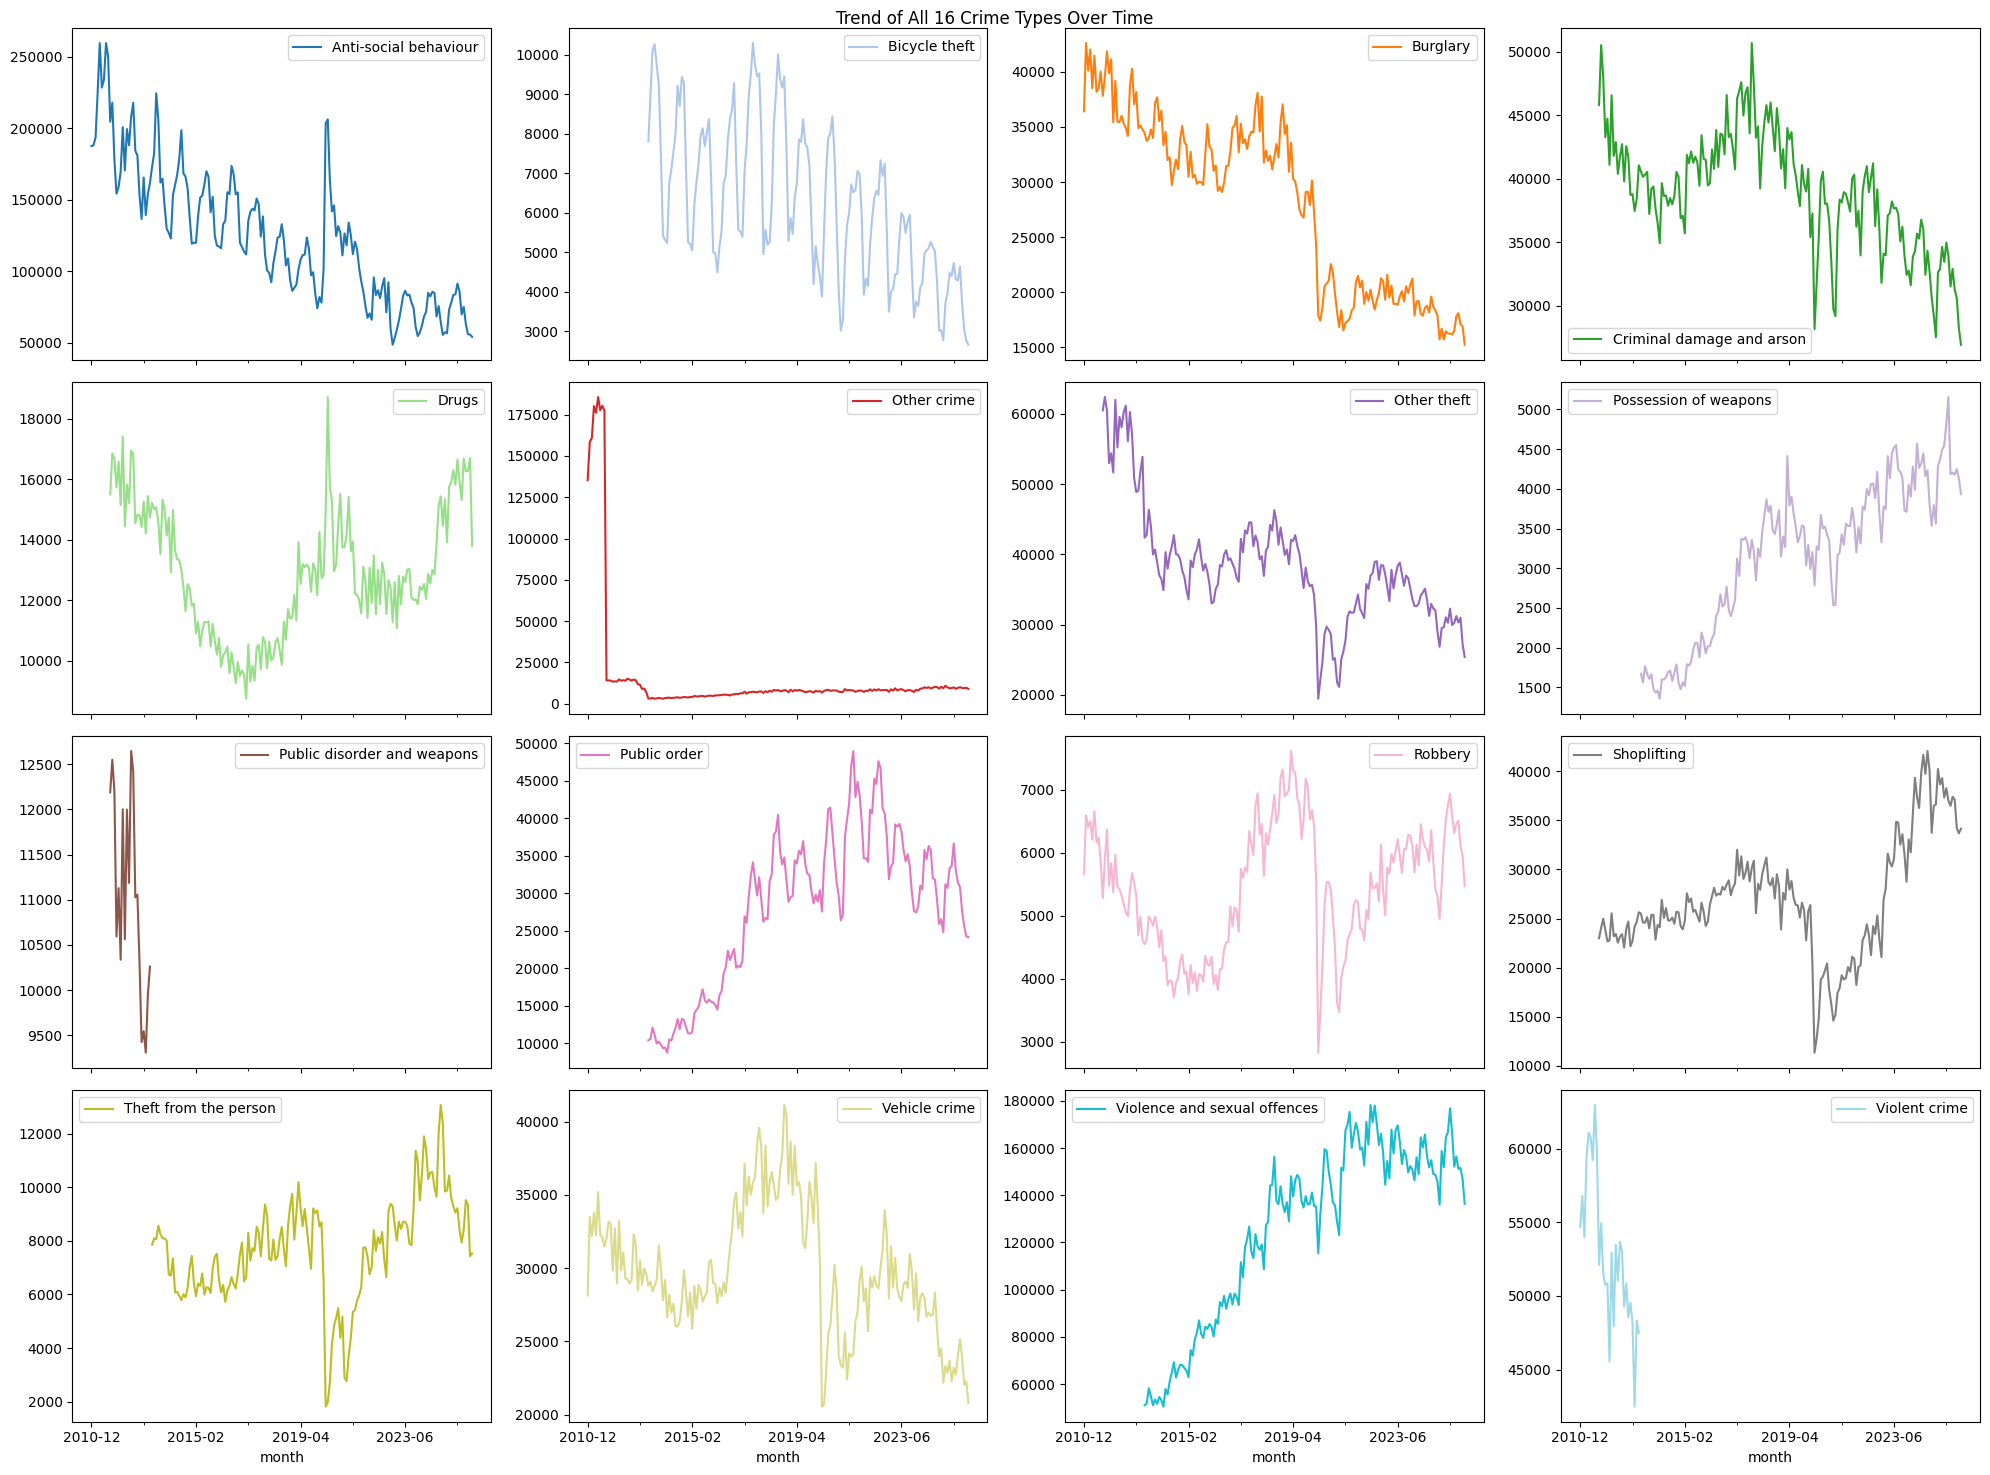

In [80]:
#4b graph raw counts against time per crime type

#query total counts per month per crime type
query = """
SELECT month, crime_type, COUNT(*) as incident_count
FROM street_crimes
GROUP BY month, crime_type
ORDER BY month;
"""
df = pd.read_sql(query, conn)

#turns month into index and creates 16 cols of crime counts
df_pivot = df.pivot(index='month', columns='crime_type', values='incident_count')

#plotting all 16
ax = df_pivot.plot(
    subplots=True,
    layout=(4, 4),
    figsize=(20, 15),
    sharex=True,
    colormap= "tab20",
    title="Trend of All 16 Crime Types Over Time"
)
plt.tight_layout()
plt.savefig('../data/crime_trends.png', dpi=300, bbox_inches='tight')
plt.show()

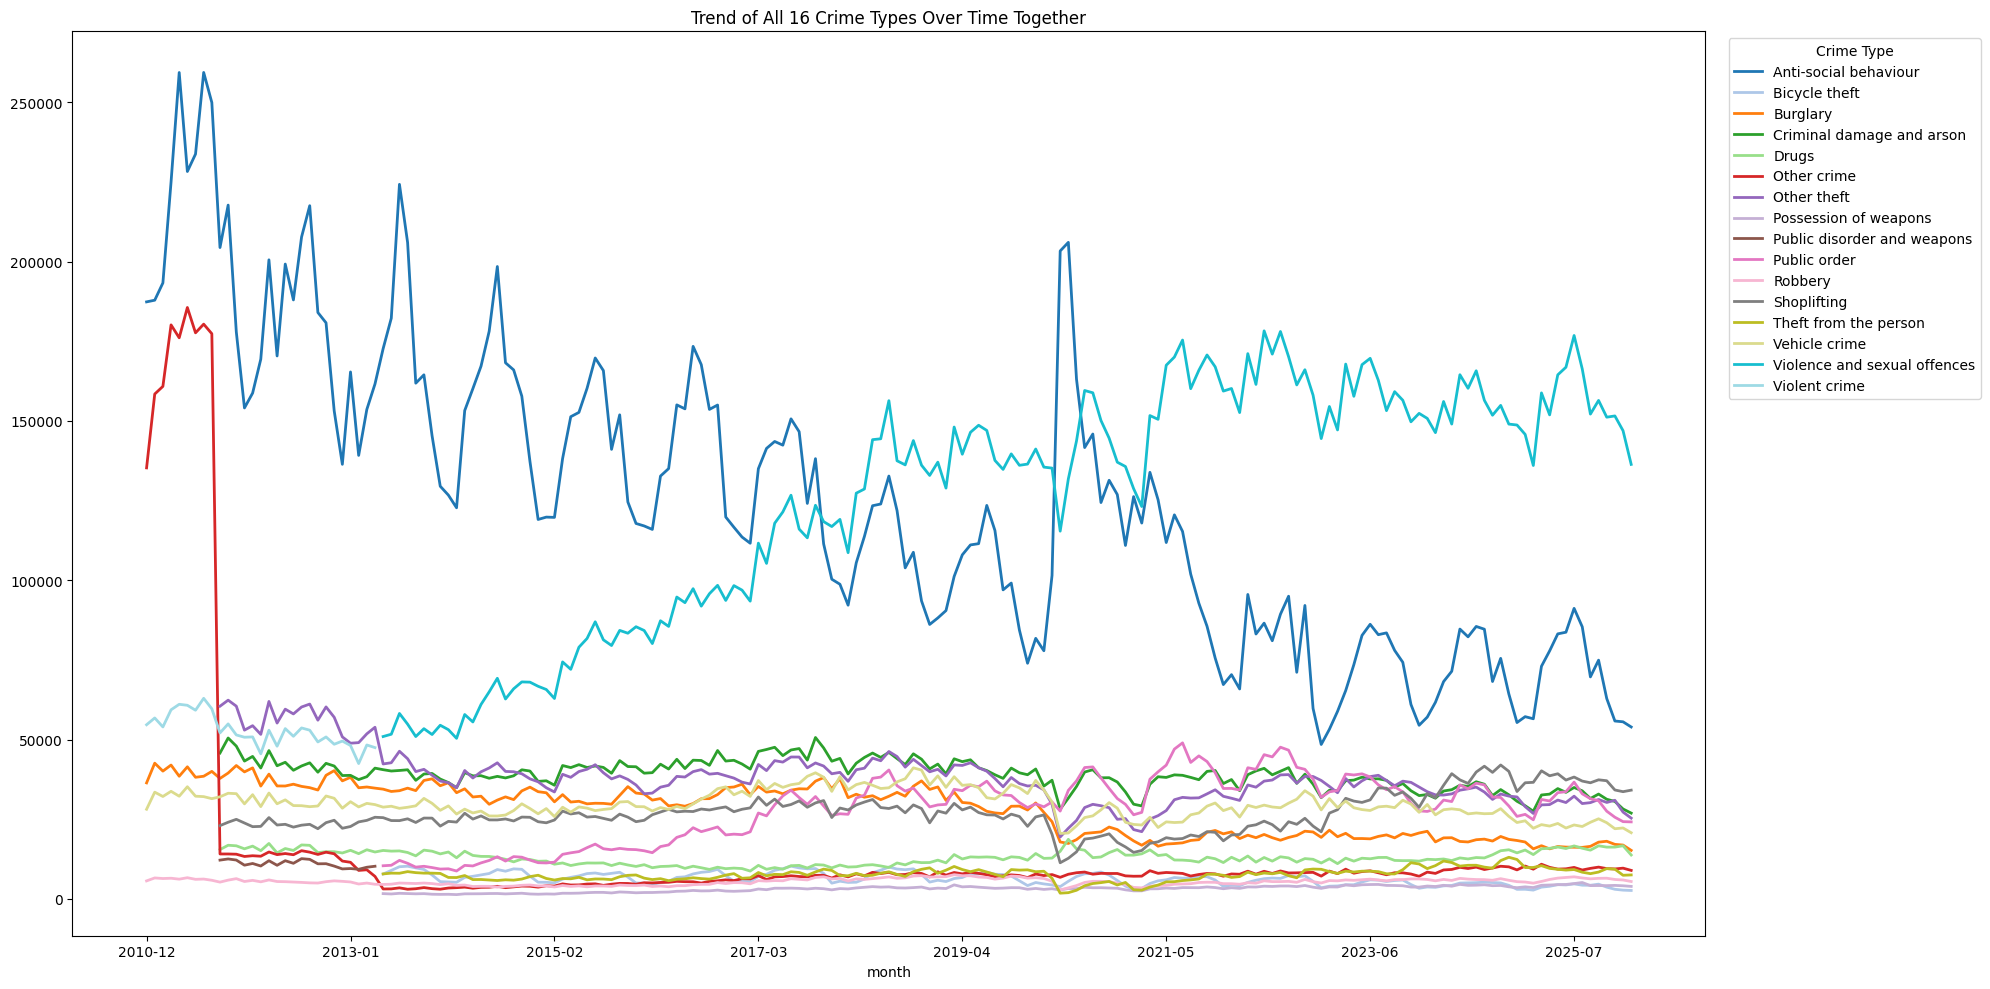

In [76]:
#4c big graph (same thing as before just subplots not on)

ax = df_pivot.plot(
    figsize=(20, 10),
    colormap="tab20",
    linewidth=2,
    title="Trend of All 16 Crime Types Over Time Together"
)

plt.legend(title='Crime Type', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../data/crime_trends_combined.png', dpi=300, bbox_inches='tight')
plt.show()

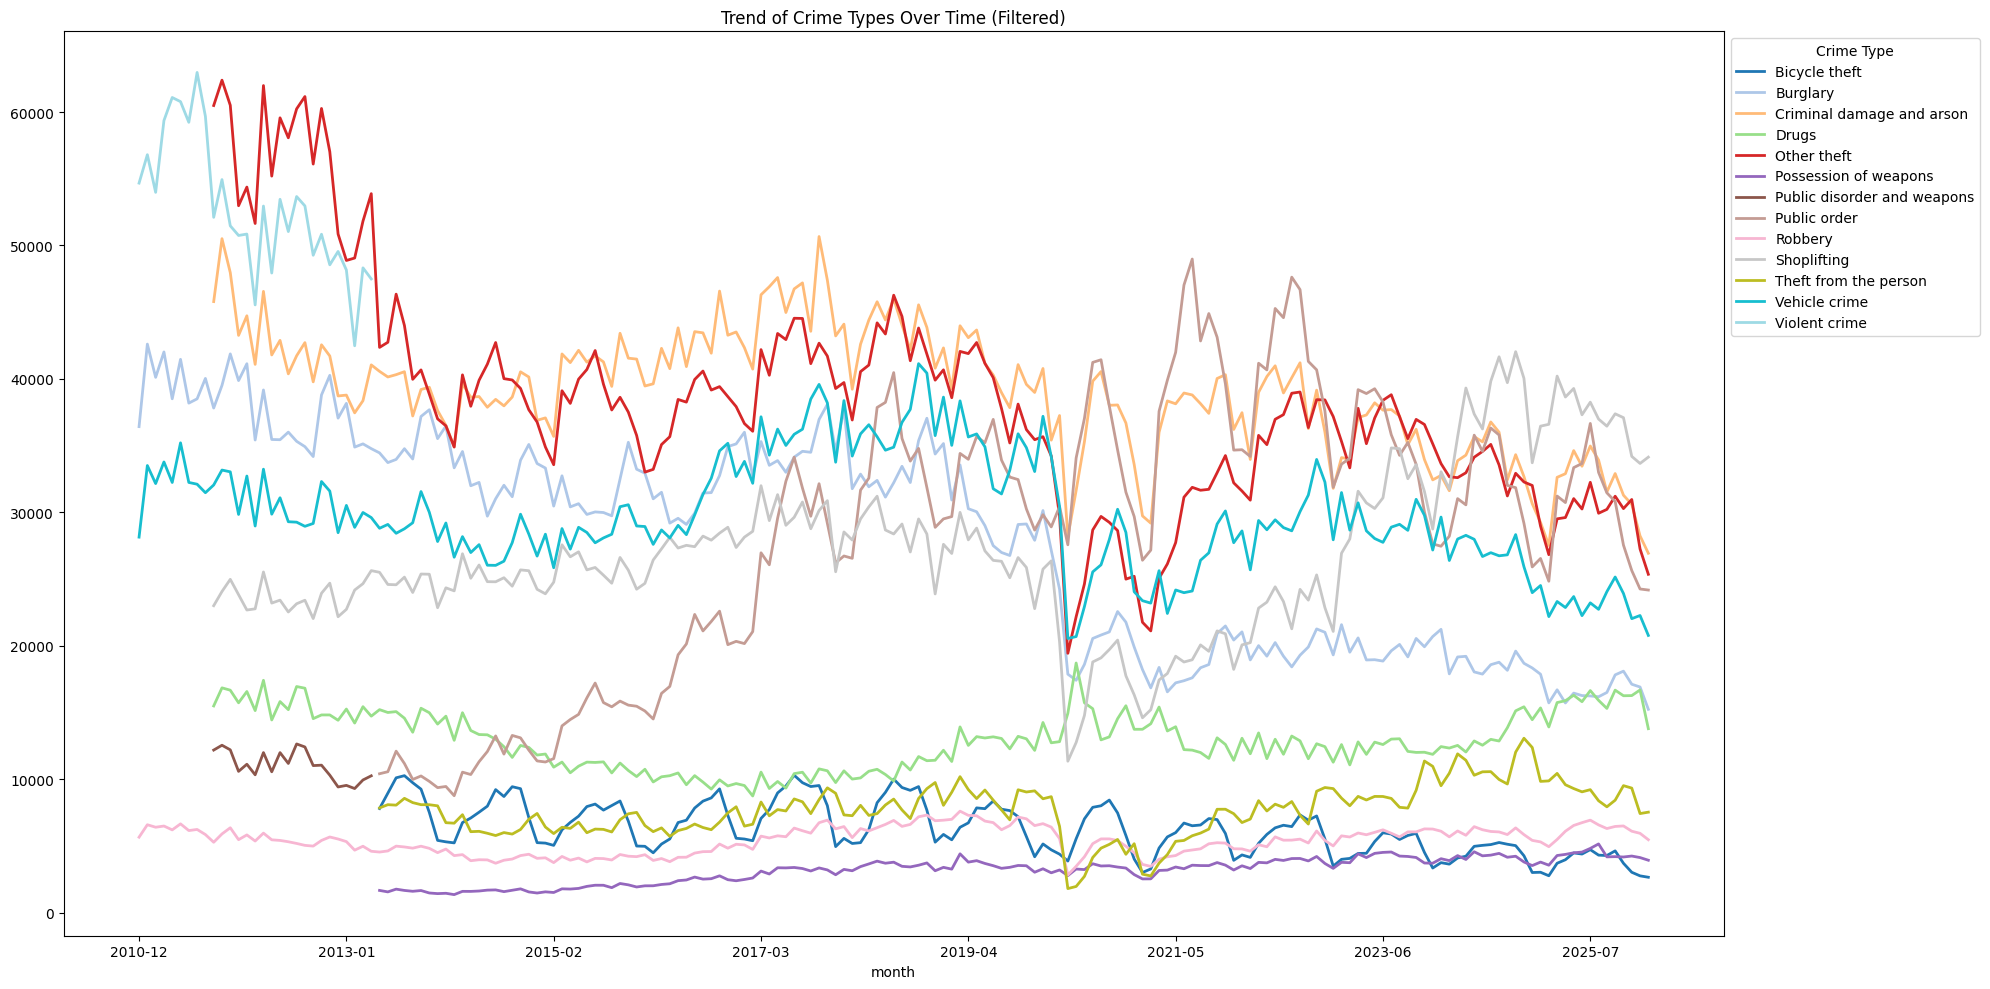

In [84]:
# 4d big graph - crimes that are too big

# crimes that are too big
crimes_to_hide = [
    "Anti-social behaviour", 
    "Other crime", 
    "Violence and sexual offences"
]
df_filtered = df_pivot.drop(columns=crimes_to_hide, errors='ignore')

ax = df_filtered.plot(
    figsize=(20, 10),     
    colormap="tab20",     
    linewidth=2,          
    title="Trend of Crime Types Over Time (Filtered)"
)

#legend to outside
plt.legend(title='Crime Type', bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../data/crime_trends_filtered.png', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
#5a double check nothing is empty in lsoa_demographics
null_query = """
SELECT 
    COUNT(*) - COUNT(lsoa_code) as missing_lsoa_code,
    COUNT(*) - COUNT(income_score) as missing_income,
    COUNT(*) - COUNT(employment_score) as missing_employment,
    COUNT(*) - COUNT(education_score) as missing_education,
    COUNT(*) - COUNT(health_score) as missing_health,
    COUNT(*) - COUNT(barrier_score) as missing_barrier,
    COUNT(*) - COUNT(living_score) as missing_living,
    COUNT(*) - COUNT(pop) as missing_pop,
    COUNT(*) - COUNT(child_pop) as missing_child,
    COUNT(*) - COUNT(old_pop) as missing_old,
    COUNT(*) - COUNT(working_pop) as missing_working
FROM lsoa_demographics;
"""
null_df = pd.read_sql(null_query, conn)
null_percentages = (null_df / total_rows) * 100
display(null_percentages.round(2).astype(str) + '%')

,missing_lsoa_code,missing_income,missing_employment,missing_education,missing_health,missing_barrier,missing_living,missing_pop,missing_child,missing_old,missing_working
0,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


In [74]:
#5 perform transformations on lsoa_demographics to match plan

#loading table into df
df = pd.read_sql("SELECT * FROM lsoa_demographics;", conn)

#calculate the scores as written in plan
df['econ_score'] = (df['income_score'] + df['employment_score']) / 2
df['infrastructure_score'] = (df['education_score'] + df['barrier_score'] + df['living_score']) / 3

#calculate pop percentages per group
df['percent_working'] = df['working_pop'] / df['pop']
df['percent_child'] = df['child_pop'] / df['pop']
df['percent_old'] = df['old_pop'] / df['pop']

#filter df to only keep the important cols
columns_to_keep = [
    'lsoa_code', 
    'pop', 
    'econ_score', 
    'infrastructure_score', 
    'health_score', 
    'percent_working', 
    'percent_child', 
    'percent_old'
]
df_clean = df[columns_to_keep]

#overwrite old table
df_clean.to_sql("lsoa_demographics", conn, if_exists="replace", index=False)

#re-apply index just in case it's dropped in process
conn.execute("CREATE UNIQUE INDEX IF NOT EXISTS idx_lsoa_code ON lsoa_demographics(lsoa_code);")
display(df_clean.head())


,lsoa_code,pop,econ_score,infrastructure_score,health_score,percent_working,percent_child,percent_old
0,E01000001,1795,0.0135,26.766333,-1.771,0.695265,0.083008,0.289694
1,E01000002,1671,0.0140,16.920667,-1.549,0.792340,0.048474,0.231598
2,E01000003,1896,0.0855,18.055667,-0.292,0.774789,0.071730,0.227848
3,E01000005,1737,0.1575,27.056667,0.436,0.833621,0.101900,0.092113
4,E01000006,1837,0.2315,31.027667,-0.372,0.685901,0.216113,0.122482


In [ ]:
#6 
#first deleting all other crime
cursor.execute("DELETE FROM street_crimes WHERE crime_type IN ('Other crime');")

#grouping violence
cursor.execute("""
    UPDATE street_crimes 
    SET crime_type = 'Violence' 
    WHERE crime_type IN ('Violence and sexual offences', 'Violent crime', 'Robbery');""")

#grouping property theft
cursor.execute("""
    UPDATE street_crimes 
    SET crime_type = 'Property theft' 
    WHERE crime_type IN ('Shoplifting', 'Theft from the person', 'Bicycle theft', 'Other theft');""")

#grouping disruptive crimes
cursor.execute("""
    UPDATE street_crimes 
    SET crime_type = 'Disruptive crimes' 
    WHERE crime_type IN ('Drugs', 'Possession of weapons', 'Public disorder and weapons', 'Public order');""")

conn.commit()

In [19]:
crime_type_query = """
SELECT crime_type, COUNT(*) as incident_count 
FROM street_crimes 
GROUP BY crime_type 
ORDER BY incident_count DESC;
"""
crime_df = pd.read_sql(crime_type_query, conn)
crime_df['percentage'] = ((crime_df['incident_count'] / total_rows) * 100).round(2)
display(crime_df)

,crime_type,incident_count,percentage
0,Anti-social behaviour,22805160,27.53
1,Violence,21856460,26.39
2,Property theft,13497125,16.29
3,Disruptive crimes,7294078,8.81
4,Criminal damage and arson,6789873,8.20
5,Vehicle crime,5455546,6.59
6,Burglary,5132164,6.20


In [61]:
#7 checking for missing lsoas in street_crimes

#clean data gathered
clean_lsoas_df = pd.read_csv("../data/lsoa_codes.csv", usecols=['LSOA21CD', 'LSOA21NM'])
total_lsoa_set = set(clean_lsoas_df['LSOA21CD'])

#get from db all lsoas
db_lsoas_df = pd.read_sql("SELECT lsoa_code FROM street_crimes;",  conn)

#i use set here so there are no duplicates
db_lsoa_set = set(db_lsoas_df['lsoa_code'])

#set difference to find which lsoa's missing from our db
missing_lsoas = total_lsoa_set - db_lsoa_set

print(f'total lsoa codes count (clean) {len(total_lsoa_set)}')
print(f'database lsoa codes count {len(db_lsoa_set)}')
print(f'number of missing lsoas {len(missing_lsoas)}')

#convert missing lsoas to series
missing_series = pd.Series(list(missing_lsoas))

#take the first letter in each code and count
code_missing = missing_series.str[0].value_counts()

print(f'missing lsoas come from {code_missing}')

#filtering the series to keep rows where it doesn't start with W (~ = not)
missing_england = missing_series[~missing_series.str.startswith('W')]
#print in list format for cleanliness
print(missing_england.tolist())

total lsoa codes count (clean) 35672
database lsoa codes count 34754
number of missing lsoas 1952
missing lsoas come from W    1917
E      35
Name: count, dtype: int64
['E01034000', 'E01033980', 'E01035704', 'E01035671', 'E01034109', 'E01034137', 'E01033978', 'E01033977', 'E01033981', 'E01033948', 'E01034136', 'E01033989', 'E01034114', 'E01034126', 'E01034132', 'E01033990', 'E01034120', 'E01034116', 'E01034134', 'E01035701', 'E01034001', 'E01035700', 'E01034108', 'E01034194', 'E01034127', 'E01034214', 'E01035698', 'E01032775', 'E01034128', 'E01034111', 'E01033995', 'E01033994', 'E01033987', 'E01034113', 'E01033984']


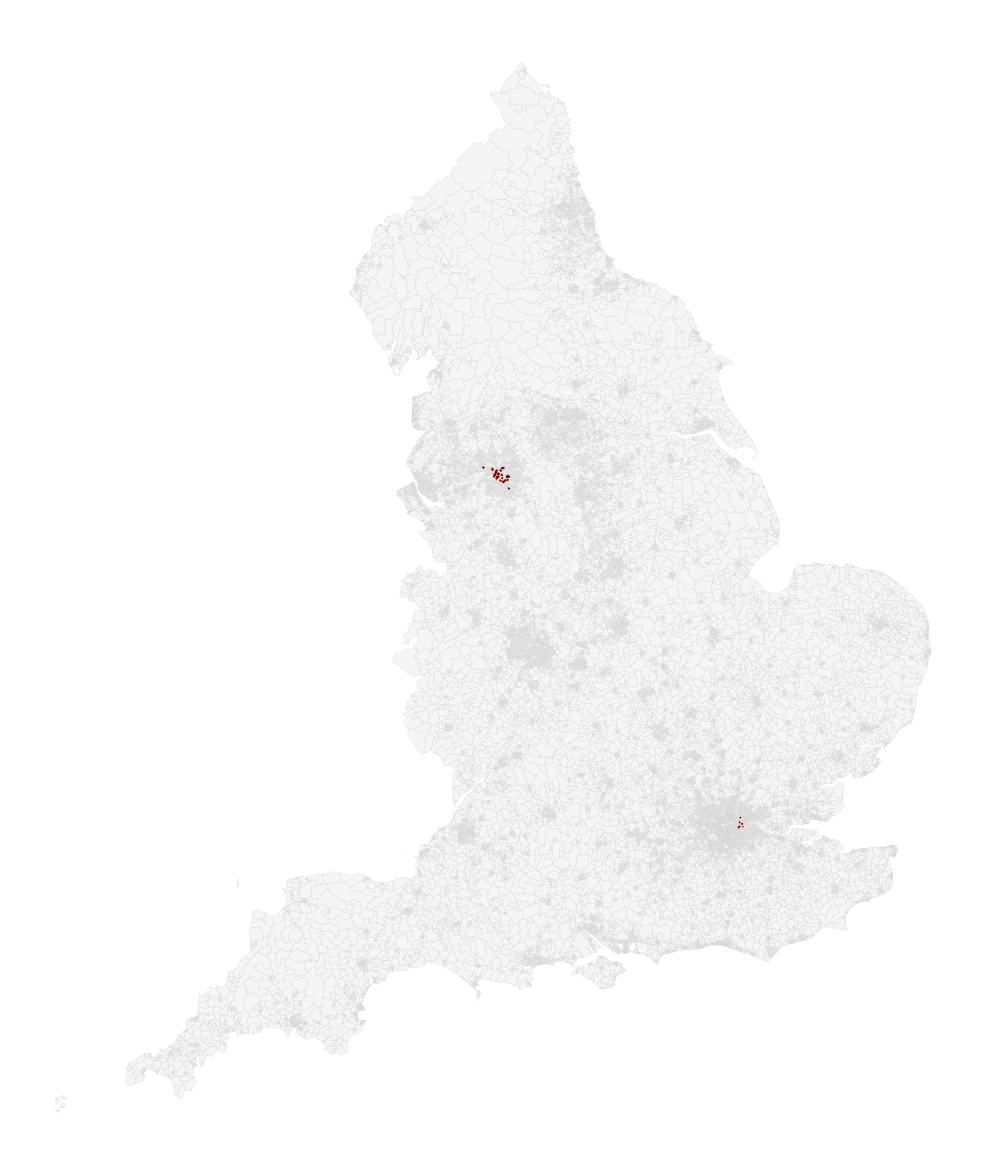

In [43]:
#7a plotting
gdf = gpd.read_file('../data/lsoa_spatial.geojson') 

missing_codes_list = missing_england.tolist()

#separate between missing and normal lsoas
england_base_map = gdf[~gdf['LSOA21CD'].str.startswith('W', na=False)]
missing_map_df = gdf[gdf['LSOA21CD'].isin(missing_codes_list)]

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

england_base_map.plot(
    ax=ax, 
    color='whitesmoke', 
    edgecolor='lightgrey', 
    linewidth=0.2
)


if not missing_map_df.empty:
    missing_map_df.plot(
        ax=ax, 
        color='red', 
        edgecolor='darkred',
        linewidth=1
    )


ax.axis('off')

plt.savefig('../data/missing_lsoas_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
#7b decoding lsoa cods
#take all lsoa_code and local authority names
df_info = pd.read_sql("SELECT lsoa_code, loc_auth_name FROM lsoa_info;", conn)

#filter df to only keep rows that have the missing codes
missing_auth_df = df_info[df_info['lsoa_code'].isin(missing_codes_list)]

#count how many codes belong to each local authority
auth_summary = missing_auth_df['loc_auth_name'].value_counts()

display(auth_summary.to_frame)

<bound method Series.to_frame of loc_auth_name
Manchester       14
Salford          10
Tower Hamlets     6
Trafford          2
Stockport         1
Greenwich         1
Newham            1
Name: count, dtype: int64>

In [55]:
#7c opposite of 7b
#take all lsoa_code and local authority names
df_info = pd.read_sql("SELECT lsoa_code, loc_auth_name FROM lsoa_info;", conn)

#filtering for normal english lsoas; code can't be in missing code list
normal_auth_df = df_info[(~df_info['lsoa_code'].isin(missing_codes_list))]

#count
normal_summary = normal_auth_df['loc_auth_name'].value_counts()

#don't hide rows
pd.set_option('display.max_rows', None)

display(normal_summary.to_frame())

,count
loc_auth_name,
Birmingham,659
Leeds,488
North Yorkshire,379
Sheffield,343
Somerset,339
Cornwall,336
Buckinghamshire,334
County Durham,330
Bradford,312


In [57]:
#7d just realized i've been using local authority code but i can map that onto police force areas just need to add more into lsoa_info
#don't run twice please!

lookup_df = pd.read_excel('../data/pfa.xlsx', usecols=['LAD21CD', 'PFA21CD', 'PFA21NM'])

#temp table in database to easily work with it 
lookup_df.to_sql('temp_police_lookup', conn, if_exists='replace', index=False)


#adding empty columns to lsoa_info
cursor.execute("ALTER TABLE lsoa_info ADD COLUMN pfa_code TEXT;")
cursor.execute("ALTER TABLE lsoa_info ADD COLUMN pfa_name TEXT;")

#matching loc_auth_code to the new temp db and then adding PFA code/name
update_query = """
UPDATE lsoa_info
SET 
    pfa_code = (SELECT PFA21CD FROM temp_police_lookup WHERE temp_police_lookup.LAD21CD = lsoa_info.loc_auth_code),
    pfa_name = (SELECT PFA21NM FROM temp_police_lookup WHERE temp_police_lookup.LAD21CD = lsoa_info.loc_auth_code);
"""
cursor.execute(update_query)

#delete temp daatabase
cursor.execute("DROP TABLE temp_police_lookup;")

conn.commit()

In [59]:
#7e redo mappings
#take all lsoa_code and pfa
df_info = pd.read_sql("SELECT lsoa_code, pfa_name FROM lsoa_info;", conn)

#filter df to only keep rows that have the missing codes
missing_auth_df = df_info[df_info['lsoa_code'].isin(missing_codes_list)]

#count how many codes belong to each pfa
auth_summary = missing_auth_df['pfa_name'].value_counts()

display(auth_summary.to_frame)

#take all lsoa_code and local authority names
df_info = pd.read_sql("SELECT lsoa_code, pfa_name FROM lsoa_info;", conn)

#filtering for normal english lsoas; code can't be in missing code list
normal_auth_df = df_info[(~df_info['lsoa_code'].isin(missing_codes_list))]

#count
normal_summary = normal_auth_df['pfa_name'].value_counts()

#don't hide rows
pd.set_option('display.max_rows', None)

display(normal_summary.to_frame())

<bound method Series.to_frame of pfa_name
Greater Manchester     27
Metropolitan Police     8
Name: count, dtype: int64>

,count
pfa_name,
Metropolitan Police,4980
West Midlands,1719
Greater Manchester,1675
Thames Valley,1485
West Yorkshire,1404
Hampshire,1231
Essex,1111
Kent,1107
Devon & Cornwall,1066


In [65]:
#7f check populations

#join to get lsoa_info and lsoa_demographics together
query = """
SELECT 
    i.lsoa_code, 
    i.pfa_name, 
    d.pop as population
FROM lsoa_info i
LEFT JOIN lsoa_demographics d ON i.lsoa_code = d.lsoa_code;
"""
df_combined = pd.read_sql(query, conn)

#filter for only missing English LSOAs
missing_df = df_combined[df_combined['lsoa_code'].isin(missing_codes_list)]

display(missing_df.sort_values('population', ascending=True))

,lsoa_code,pfa_name,population
32177,E01034136,Greater Manchester,940
32019,E01033978,Greater Manchester,961
33691,E01035698,Metropolitan Police,1064
32018,E01033977,Greater Manchester,1084
32157,E01034116,Greater Manchester,1152
32175,E01034134,Greater Manchester,1183
31081,E01032775,Metropolitan Police,1194
32021,E01033980,Greater Manchester,1227
32028,E01033987,Greater Manchester,1239
32036,E01033995,Greater Manchester,1249


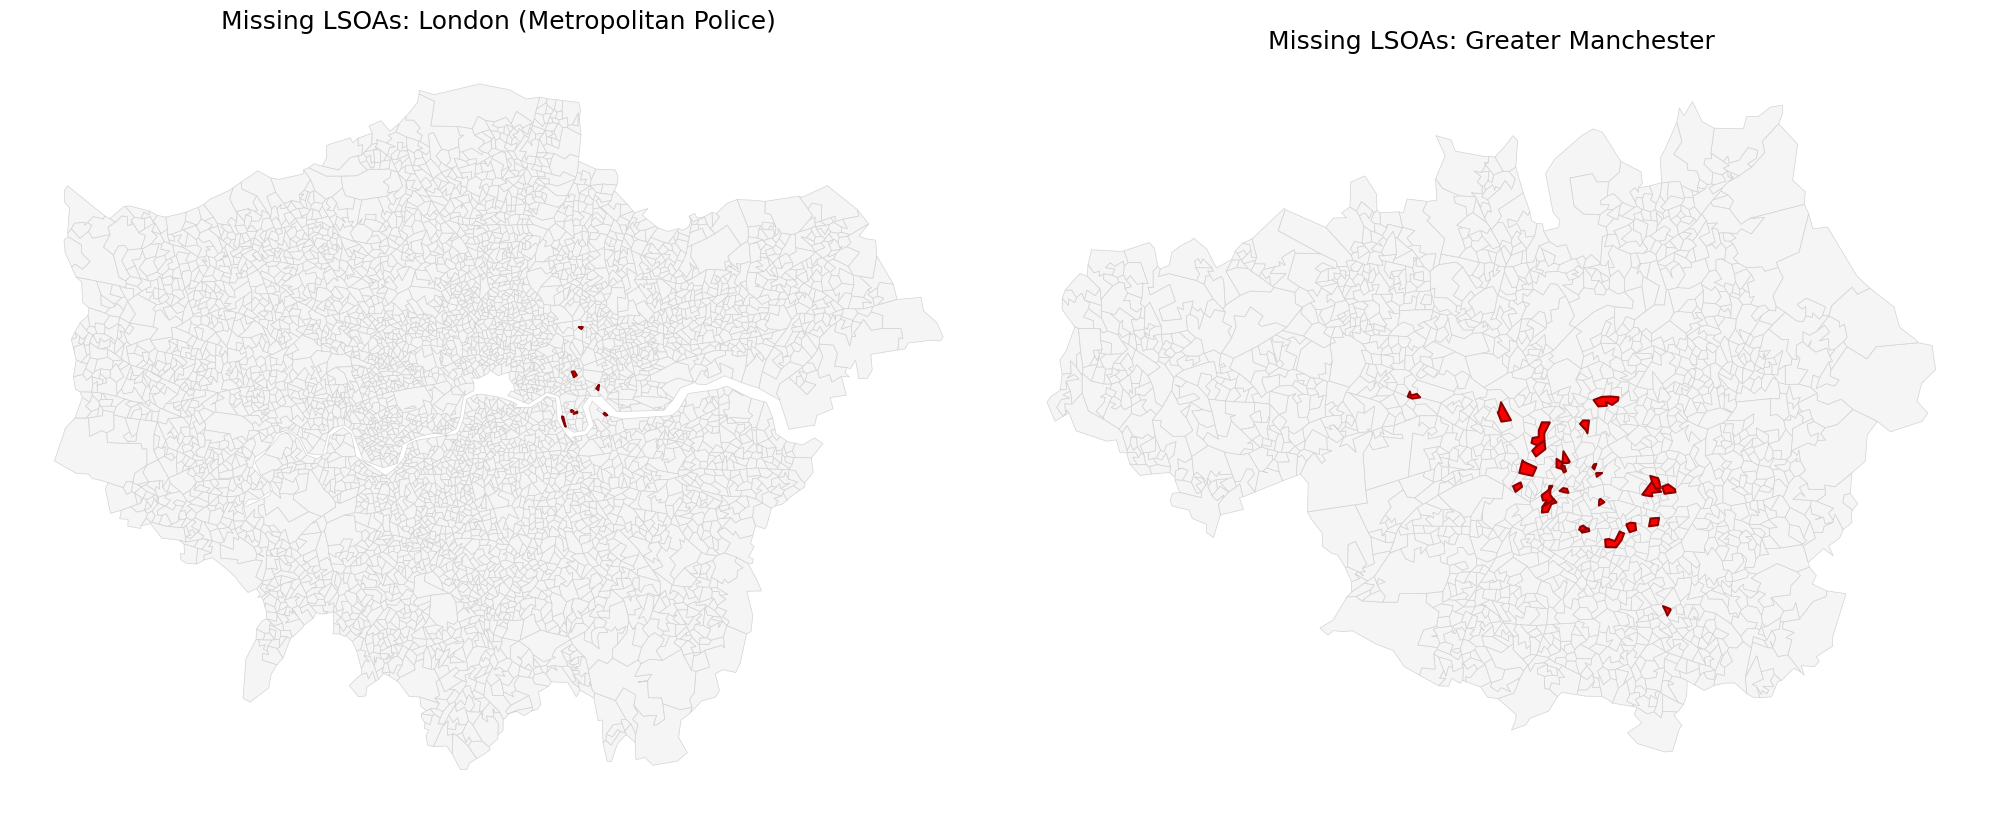

In [71]:
#7g make an in depth map of the two areas
df_info = pd.read_sql("SELECT lsoa_code, pfa_name FROM lsoa_info;", conn)

gdf = gpd.read_file('../data/lsoa_spatial.geojson')

#merge shapes w/ police force names
map_with_police = gdf.merge(df_info, left_on='LSOA21CD', right_on='lsoa_code', how='inner')

#base maps
london_base = map_with_police[map_with_police['pfa_name'] == 'Metropolitan Police']
manchester_base = map_with_police[map_with_police['pfa_name'] == 'Greater Manchester']

#grab the specific missing lsoas
london_missing = london_base[london_base['LSOA21CD'].isin(missing_codes_list)]
manchester_missing = manchester_base[manchester_base['LSOA21CD'].isin(missing_codes_list)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

#london map
london_base.plot(ax=ax1, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5)
if not london_missing.empty:
    london_missing.plot(ax=ax1, color='red', edgecolor='darkred', linewidth=1.5)
ax1.axis('off')
ax1.set_title("Missing LSOAs: London (Metropolitan Police)", fontsize=18, pad=15)

#machester map
manchester_base.plot(ax=ax2, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5)
if not manchester_missing.empty:
    manchester_missing.plot(ax=ax2, color='red', edgecolor='darkred', linewidth=1.5)
ax2.axis('off')
ax2.set_title("Missing LSOAs: Greater Manchester", fontsize=18, pad=15)

# 7. Save and show
plt.tight_layout()
plt.savefig('../data/missing_indepth_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
#8
#deletes table if exists to let me re-run multiple times
cursor.execute("DROP TABLE IF EXISTS lsoa_month;")

create_table_query = """
CREATE TABLE lsoa_month (
    lsoa_code TEXT,
    month TEXT,
    crime_type TEXT,
    crime_count INTEGER,
    PRIMARY KEY (lsoa_code, month, crime_type)
);
"""
cursor.execute(create_table_query)


#zero-padding aggregation query
aggregate_insert_query = """
INSERT INTO lsoa_month (lsoa_code, month, crime_type, crime_count)

WITH 
    unique_lsoas AS (SELECT DISTINCT lsoa_code FROM street_crimes),
    unique_months AS (SELECT DISTINCT month FROM street_crimes),
    unique_crimes AS (SELECT DISTINCT crime_type FROM street_crimes),
    
    master_grid AS (
        SELECT l.lsoa_code, m.month, c.crime_type
        FROM unique_lsoas l
        CROSS JOIN unique_months m
        CROSS JOIN unique_crimes c
    ),
    
    actual_crimes AS (
        SELECT lsoa_code, month, crime_type, COUNT(*) as count
        FROM street_crimes
        GROUP BY lsoa_code, month, crime_type
    )

SELECT 
    g.lsoa_code, 
    g.month, 
    g.crime_type, 
    COALESCE(a.count, 0) as crime_count
FROM master_grid g
LEFT JOIN actual_crimes a 
    ON g.lsoa_code = a.lsoa_code 
    AND g.month = a.month 
    AND g.crime_type = a.crime_type;
"""
cursor.execute(aggregate_insert_query)
conn.commit()

#check
check_query = "SELECT * FROM lsoa_month LIMIT 10;"
check_df = pd.read_sql(check_query, conn)
display(check_df)

total_rows = pd.read_sql("SELECT COUNT(*) as total FROM lsoa_month;", conn).iloc[0,0]
print(total_rows)

,lsoa_code,month,crime_type,crime_count
0,E01000001,2010-12,Anti-social behaviour,2
1,E01000001,2010-12,Vehicle crime,0
2,E01000001,2010-12,Violence,1
3,E01000001,2010-12,Disruptive crimes,0
4,E01000001,2010-12,Property theft,0
5,E01000001,2010-12,Burglary,0
6,E01000001,2010-12,Criminal damage and arson,0
7,E01000001,2011-01,Anti-social behaviour,2
8,E01000001,2011-01,Vehicle crime,1
9,E01000001,2011-01,Violence,1


44519874


In [5]:
zero_query = "SELECT COUNT(*) FROM lsoa_month WHERE crime_count = 0;"

zero_count = pd.read_sql(zero_query, conn).iloc[0, 0]
print(zero_count)

20225332


In [7]:
#9
#adding blank columns
cursor.execute('ALTER TABLE lsoa_month ADD COLUMN "3mo_ra" REAL;')
cursor.execute('ALTER TABLE lsoa_month ADD COLUMN "6mo_ra" REAL;')
cursor.execute('ALTER TABLE lsoa_month ADD COLUMN "12mo_diff_safe" INTEGER;')


#3 month rolling average
query_3mo = """
WITH calc AS (
    SELECT lsoa_code, month, crime_type,
           AVG(crime_count) OVER (
               PARTITION BY lsoa_code, crime_type 
               ORDER BY month 
               ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
           ) as val
    FROM lsoa_month
)
UPDATE lsoa_month
SET "3mo_ra" = calc.val
FROM calc
WHERE lsoa_month.lsoa_code = calc.lsoa_code
  AND lsoa_month.month = calc.month
  AND lsoa_month.crime_type = calc.crime_type;
"""
cursor.execute(query_3mo)

#6 month rolling average
query_6mo = """
WITH calc AS (
    SELECT lsoa_code, month, crime_type,
           AVG(crime_count) OVER (
               PARTITION BY lsoa_code, crime_type 
               ORDER BY month 
               ROWS BETWEEN 6 PRECEDING AND 1 PRECEDING
           ) as val
    FROM lsoa_month
)
UPDATE lsoa_month
SET "6mo_ra" = calc.val
FROM calc
WHERE lsoa_month.lsoa_code = calc.lsoa_code
  AND lsoa_month.month = calc.month
  AND lsoa_month.crime_type = calc.crime_type;
"""
cursor.execute(query_6mo)

#12 mo diff (t-1)-(t-13)
query_12mo = """
WITH calc AS (
    SELECT lsoa_code, month, crime_type,
           LAG(crime_count, 1) OVER (PARTITION BY lsoa_code, crime_type ORDER BY month) 
           - 
           LAG(crime_count, 13) OVER (PARTITION BY lsoa_code, crime_type ORDER BY month) as val
    FROM lsoa_month
)
UPDATE lsoa_month
SET "12mo_diff_safe" = calc.val
FROM calc
WHERE lsoa_month.lsoa_code = calc.lsoa_code
  AND lsoa_month.month = calc.month
  AND lsoa_month.crime_type = calc.crime_type;
"""
cursor.execute(query_12mo)

conn.commit()

In [16]:
#9a spatial lag followed as closely as i could the tutorial

crime_df = pd.read_sql("SELECT lsoa_code, month, crime_type, crime_count FROM lsoa_month;", conn)

#get all lsoas present in our crime data
valid_lsoas = crime_df['lsoa_code'].unique()

#loading geojson + filtering out missing 35 lsoas
gdf = gpd.read_file('../data/lsoa_spatial.geojson')
gdf = gdf[gdf['LSOA21CD'].isin(valid_lsoas)]

#sorting df
gdf = gdf.sort_values('LSOA21CD').reset_index(drop=True)

#building pysal spatial weights matrix; queen contiguity considers polygons as neighbors if they share at least one edge or vertex 
w = libpysal.weights.Queen.from_dataframe(gdf, idVariable='LSOA21CD')

#row-standardize weights
w.transform = 'R'

#changed from tutorial; makes a wide table where rows = lsoa columns=month,crime_type
wide_crimes = crime_df.pivot(index='lsoa_code', columns=['month', 'crime_type'], values='crime_count')

#reordering df rows to match pysal weights matrix id order
wide_crimes = wide_crimes.reindex(w.id_order)

#calculate the spatial lag for every month and crime type at same time; standard matrix multiplication: Y_lag = W * Y
lagged_wide = pd.DataFrame(
    w.sparse.dot(wide_crimes.fillna(0)), 
    index=w.id_order, 
    columns=wide_crimes.columns
)

#format back to db
lagged_long = lagged_wide.reset_index().melt(
    id_vars='index', 
    value_name='spatial_lag'
).rename(columns={'index': 'lsoa_code'})

#back to db
cursor.execute("ALTER TABLE lsoa_month ADD COLUMN spatial_lag REAL;")
lagged_long.to_sql('temp_spatial_lag', conn, if_exists='replace', index=False)

update_query = """
UPDATE lsoa_month
SET spatial_lag = temp_spatial_lag.spatial_lag
FROM temp_spatial_lag
WHERE lsoa_month.lsoa_code = temp_spatial_lag.lsoa_code
  AND lsoa_month.month = temp_spatial_lag.month
  AND lsoa_month.crime_type = temp_spatial_lag.crime_type;
"""
cursor.execute(update_query)

cursor.execute("DROP TABLE temp_spatial_lag;")
conn.commit()


/var/folders/5j/qnwqt2_51b10frpqklssz0nw0000gn/T/ipykernel_89357/2185524017.py:16: FutureWarning: `idVariable` is deprecated and will be removed in future. Use `ids` instead.
  w = libpysal.weights.Queen.from_dataframe(gdf, idVariable='LSOA21CD')
/opt/anaconda3/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There is 1 island with id: E01019077.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 'E01019077', ' is an island (no neighbors)')


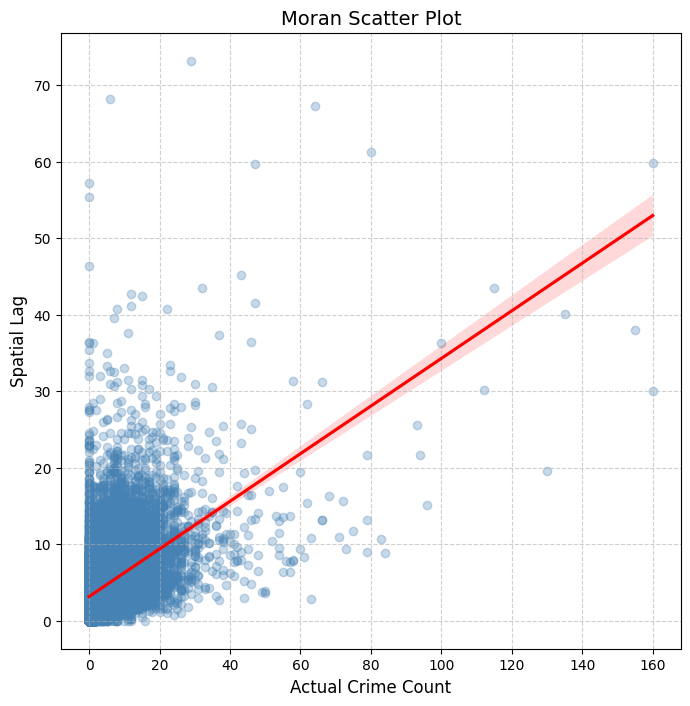

In [40]:
#9b moran plot
conn = sqlite3.connect('../data/police_data.db')
df = pd.read_sql("""
    SELECT crime_count, spatial_lag 
    FROM lsoa_month 
    WHERE crime_type = 'Violence' 
      AND month = '2023-01'
""", conn)

plt.figure(figsize=(8, 8))
sns.regplot(
    x='crime_count', 
    y='spatial_lag', 
    data=df, 
    scatter_kws={'alpha':0.3, 'color': 'steelblue'}, 
    line_kws={'color':'red'}
)

plt.title("Moran Scatter Plot", fontsize=14)
plt.xlabel("Actual Crime Count", fontsize=12)
plt.ylabel("Spatial Lag", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

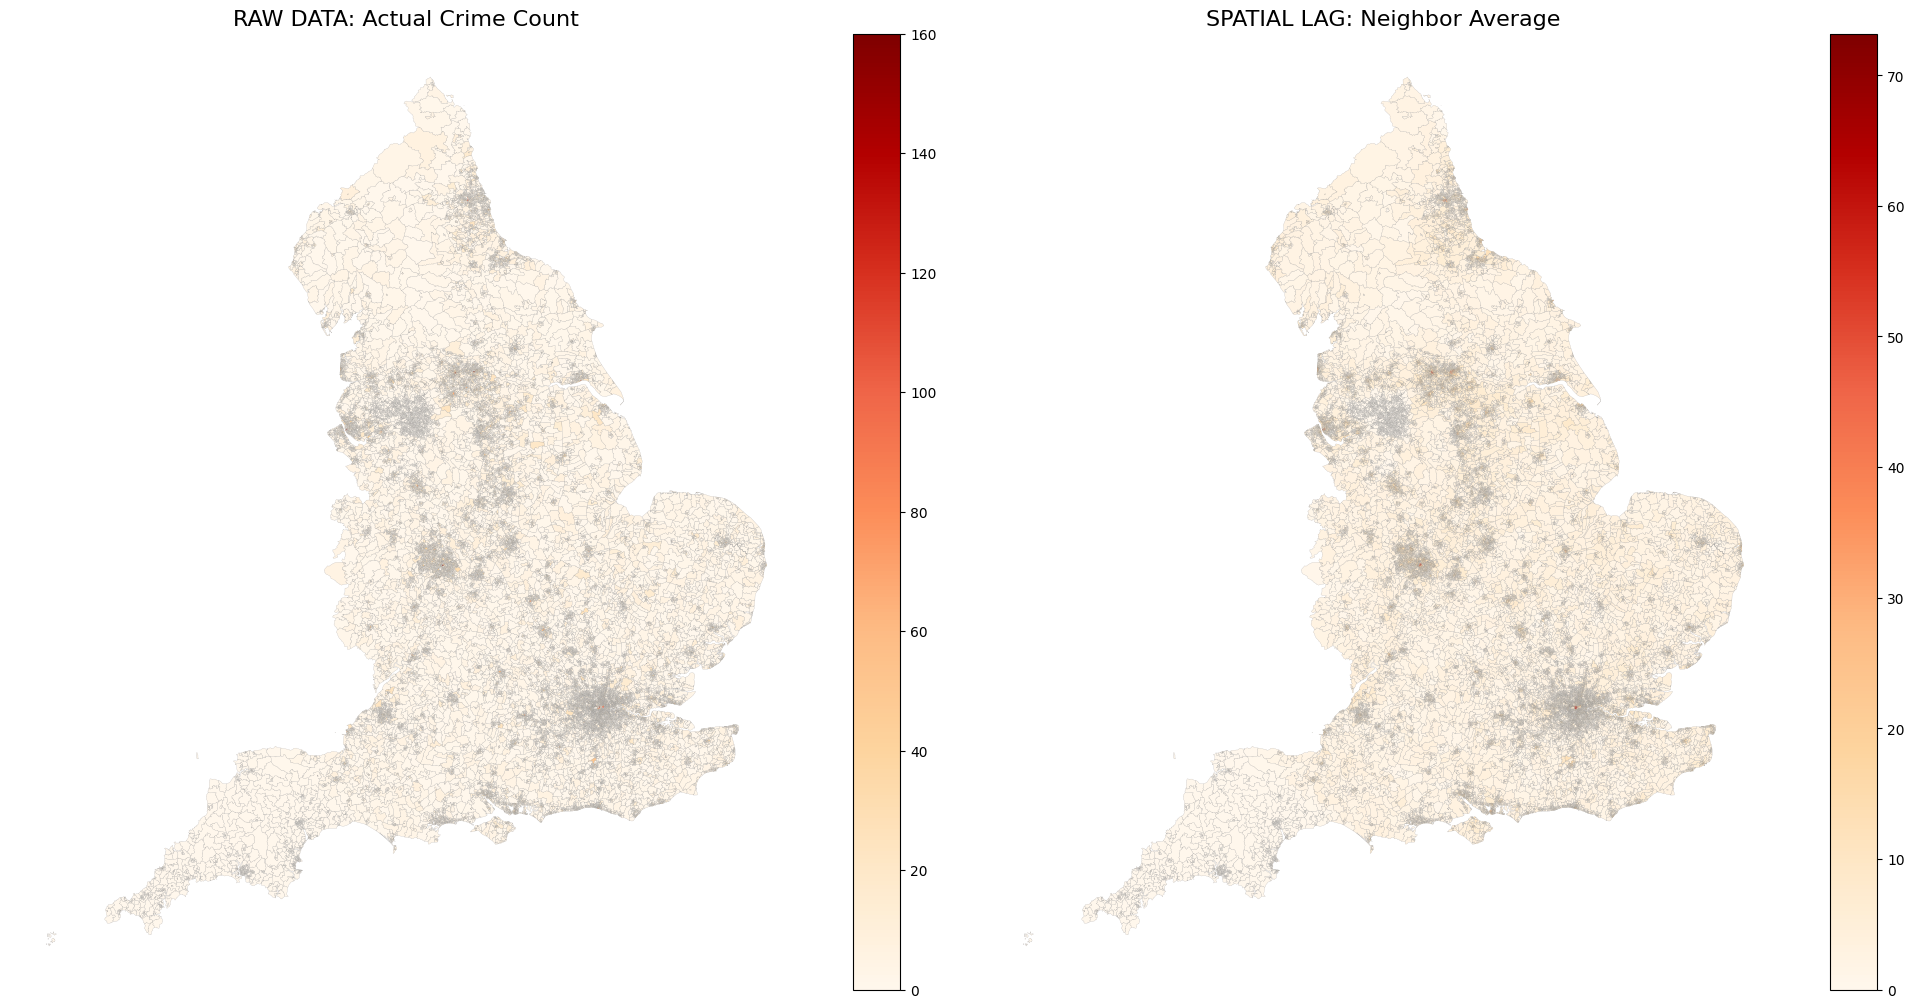

In [28]:
#9c done w/ gemini; maps of spatial vs. actual crime
df_map = pd.read_sql("""
    SELECT lsoa_code, crime_count, spatial_lag 
    FROM lsoa_month 
    WHERE crime_type = 'Violence' 
      AND month = '2023-01'
""", conn)

# 2. Load the map and merge our data
gdf = gpd.read_file('../data/lsoa_spatial.geojson')
gdf_merged = gdf.merge(df_map, left_on='LSOA21CD', right_on='lsoa_code', how='inner')

# 3. Plot them side-by-side!
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Map 1: Raw Crime
gdf_merged.plot(
    column='crime_count', 
    cmap='OrRd', # Orange-Red color scale
    linewidth=0.1, 
    edgecolor='grey', 
    legend=True, 
    ax=ax1
)
ax1.set_title('RAW DATA: Actual Crime Count', fontsize=16)
ax1.axis('off')

# Map 2: Spatial Lag
gdf_merged.plot(
    column='spatial_lag', 
    cmap='OrRd', 
    linewidth=0.1, 
    edgecolor='grey', 
    legend=True, 
    ax=ax2
)
ax2.set_title('SPATIAL LAG: Neighbor Average', fontsize=16)
ax2.axis('off')

plt.tight_layout()
plt.show()

Pulling and aggregating total crimes per LSOA...

--- Distribution Summary Table ---


,Total Crimes per Month
count,6359982.00
mean,13.02
std,19.64
min,0.00
25%,4.00
50%,9.00
75%,16.00
max,2007.00


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


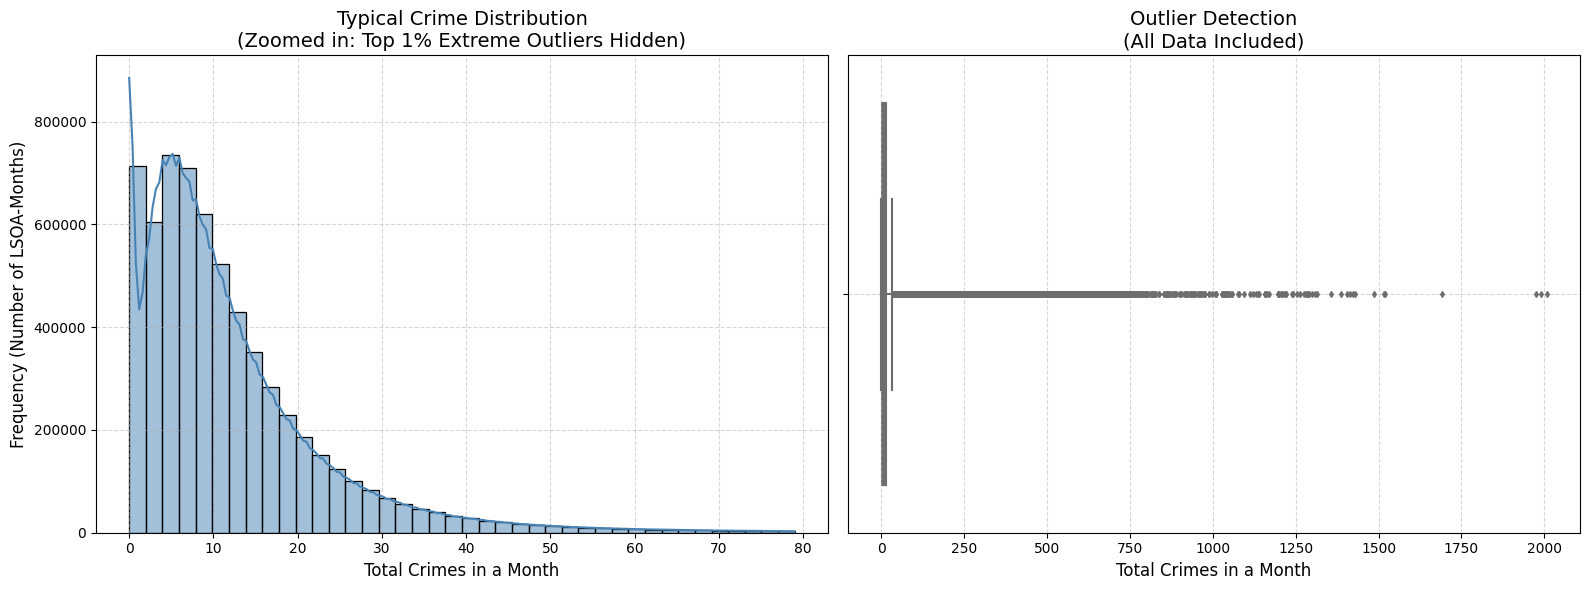

In [31]:
#9d; done w/ gemini; checking distributions

print("Pulling and aggregating total crimes per LSOA...")
# 1. Sum up all crime types to get the TOTAL crimes per LSOA per month
query = """
SELECT lsoa_code, month, SUM(crime_count) as total_monthly_crimes
FROM lsoa_month
GROUP BY lsoa_code, month;
"""
df_totals = pd.read_sql(query, conn)

# 2. Create the Summary Table
# describe() automatically calculates the mean, median, percentiles, and outliers
summary_table = df_totals['total_monthly_crimes'].describe().to_frame(name='Total Crimes per Month')
summary_table = summary_table.round(2)

print("\n--- Distribution Summary Table ---")
display(summary_table)

# 3. Create the Graphs
# We set up a 1x2 grid so we can see the distribution and the outliers side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: The Histogram (The "Normal" Distribution) ---
# Extreme outliers ruin histograms, so we calculate the 99th percentile and temporarily hide the top 1% just for this graph
p99 = df_totals['total_monthly_crimes'].quantile(0.99)
normal_data = df_totals[df_totals['total_monthly_crimes'] <= p99]

sns.histplot(data=normal_data, x='total_monthly_crimes', bins=40, kde=True, ax=ax1, color='steelblue')
ax1.set_title('Typical Crime Distribution\n(Zoomed in: Top 1% Extreme Outliers Hidden)', fontsize=14)
ax1.set_xlabel('Total Crimes in a Month', fontsize=12)
ax1.set_ylabel('Frequency (Number of LSOA-Months)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Graph 2: The Boxplot (The Outlier Detector) ---
# We use the FULL dataset here. Every dot outside the main box is a statistical outlier.
sns.boxplot(data=df_totals, x='total_monthly_crimes', ax=ax2, color='lightcoral', fliersize=3)
ax2.set_title('Outlier Detection\n(All Data Included)', fontsize=14)
ax2.set_xlabel('Total Crimes in a Month', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [38]:
#9e done w gemini; finding the outliers

print("Hunting down the extreme outliers...")

# This query finds any neighborhood/month combo that has over 800 crimes, 
# and shows us exactly how that number was built.
query = """
WITH Massive_Months AS (
    SELECT lsoa_code, month, SUM(crime_count) as total_crimes
    FROM lsoa_month
    GROUP BY lsoa_code, month
    HAVING SUM(crime_count) > 800  -- Adjust this threshold if needed
)
SELECT 
    m.lsoa_code, 
    m.month, 
    m.total_crimes,
    l.crime_type,
    l.crime_count
FROM Massive_Months m
JOIN lsoa_month l 
  ON m.lsoa_code = l.lsoa_code AND m.month = l.month
ORDER BY m.total_crimes DESC, m.lsoa_code, m.month, l.crime_count DESC
LIMIT 30;
"""

outliers_df = pd.read_sql(query, conn)

display(outliers_df)

Hunting down the extreme outliers...


,lsoa_code,month,total_crimes,crime_type,crime_count
0,E01035716,2023-11,2007,Property theft,1627
1,E01035716,2023-11,2007,Violence,158
2,E01035716,2023-11,2007,Disruptive crimes,69
3,E01035716,2023-11,2007,Anti-social behaviour,65
4,E01035716,2023-11,2007,Vehicle crime,52
5,E01035716,2023-11,2007,Burglary,27
6,E01035716,2023-11,2007,Criminal damage and arson,9
7,E01035716,2023-12,1990,Property theft,1573
8,E01035716,2023-12,1990,Violence,177
9,E01035716,2023-12,1990,Anti-social behaviour,95


Aggregating raw street crimes per LSOA...

--- Distribution Summary Table (From Raw Data) ---


,Total Crimes per Month (Raw)
count,5831191.0
mean,14.2
std,20.1
min,1.0
25%,5.0
50%,10.0
75%,17.0
max,2007.0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


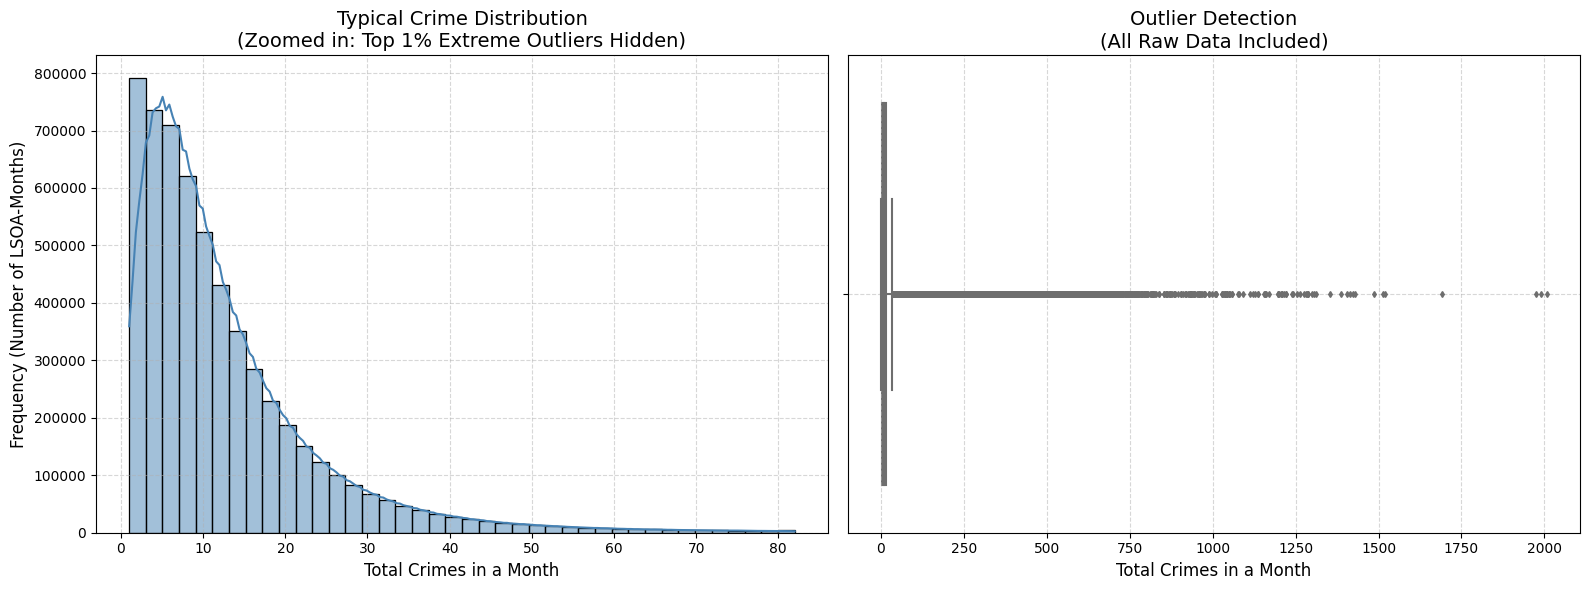

In [35]:
#9f done w/ gemini; checking the raw data

print("Aggregating raw street crimes per LSOA...")
# 1. Count the raw rows to get the TOTAL crimes per LSOA per month
query = """
SELECT lsoa_code, month, COUNT(*) as total_monthly_crimes
FROM street_crimes
GROUP BY lsoa_code, month;
"""
df_totals = pd.read_sql(query, conn)

# 2. Create the Summary Table
summary_table = df_totals['total_monthly_crimes'].describe().to_frame(name='Total Crimes per Month (Raw)')
summary_table = summary_table.round(2)

print("\n--- Distribution Summary Table (From Raw Data) ---")
display(summary_table)

# 3. Create the Graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: The Histogram (The "Normal" Distribution) ---
p99 = df_totals['total_monthly_crimes'].quantile(0.99)
normal_data = df_totals[df_totals['total_monthly_crimes'] <= p99]

sns.histplot(data=normal_data, x='total_monthly_crimes', bins=40, kde=True, ax=ax1, color='steelblue')
ax1.set_title('Typical Crime Distribution\n(Zoomed in: Top 1% Extreme Outliers Hidden)', fontsize=14)
ax1.set_xlabel('Total Crimes in a Month', fontsize=12)
ax1.set_ylabel('Frequency (Number of LSOA-Months)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Graph 2: The Boxplot (The Outlier Detector) ---
sns.boxplot(data=df_totals, x='total_monthly_crimes', ax=ax2, color='lightcoral', fliersize=3)
ax2.set_title('Outlier Detection\n(All Raw Data Included)', fontsize=14)
ax2.set_xlabel('Total Crimes in a Month', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Calculating the personal monthly average for each LSOA...

--- Distribution of LSOA Averages ---


,Average Monthly Crimes
count,34754.00
mean,13.02
std,17.02
min,0.01
25%,5.59
50%,9.30
75%,15.29
max,634.14


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


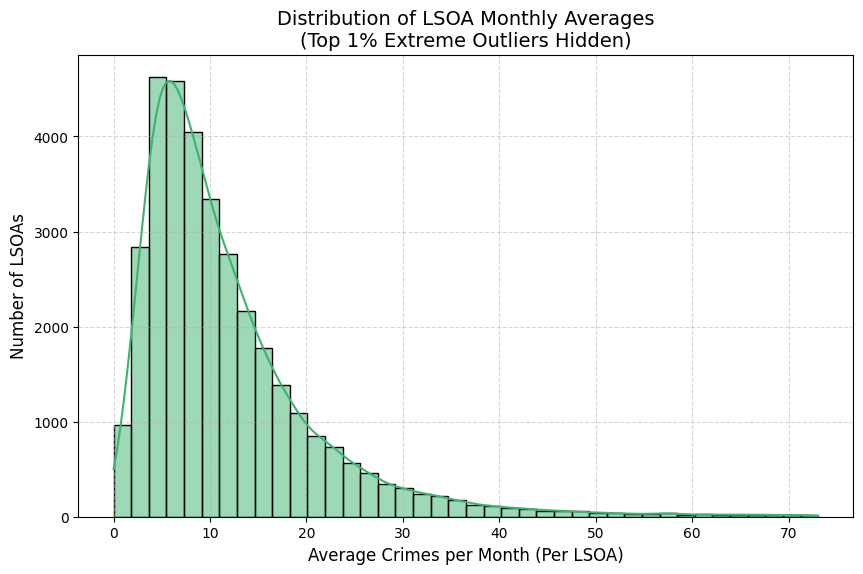

In [33]:
#9g done w/ gemini

print("Calculating the personal monthly average for each LSOA...")
# We do this in two steps inside SQL:
# 1. Sum up the total crimes per month (what we did before)
# 2. Average those monthly totals for each specific LSOA
query = """
WITH monthly_totals AS (
    SELECT lsoa_code, month, SUM(crime_count) as total_crimes
    FROM lsoa_month
    GROUP BY lsoa_code, month
)
SELECT lsoa_code, AVG(total_crimes) as lsoa_monthly_average
FROM monthly_totals
GROUP BY lsoa_code;
"""
df_lsoa_averages = pd.read_sql(query, conn)
conn.close()

# 1. The Summary Table (Now exactly 33,000 rows - one for each LSOA)
summary_table = df_lsoa_averages['lsoa_monthly_average'].describe().to_frame(name='Average Monthly Crimes')
summary_table = summary_table.round(2)

print("\n--- Distribution of LSOA Averages ---")
display(summary_table)

# 2. The Graph
plt.figure(figsize=(10, 6))
# Hiding the top 1% outliers again so the graph is readable
p99 = df_lsoa_averages['lsoa_monthly_average'].quantile(0.99)
normal_data = df_lsoa_averages[df_lsoa_averages['lsoa_monthly_average'] <= p99]

sns.histplot(data=normal_data, x='lsoa_monthly_average', bins=40, kde=True, color='mediumseagreen')
plt.title('Distribution of LSOA Monthly Averages\n(Top 1% Extreme Outliers Hidden)', fontsize=14)
plt.xlabel('Average Crimes per Month (Per LSOA)', fontsize=12)
plt.ylabel('Number of LSOAs', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [42]:
conn.close()